In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score

In [5]:
housing=pd.read_csv("/home/oem/housing.csv")

In [6]:
housing.info()
housing.describe()
housing.head()
housing.shape
housing.size

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Correlation Coefficient:: median_house_value    1.000000
median_income         0.688075
rooms_per_dwelling    0.151948
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


In [8]:
x=housing['rooms_per_dwelling'].values
y=housing['median_house_value'].values

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
x_mean=np.mean(x_train)
x_std=np.std(x_train)
x_train_scaled = (x_train - x_mean) / x_std
x_test_scaled = (x_test - x_mean) / x_std
x_train_ne=np.c_[np.ones(len(x_train)),x_train_scaled]

In [13]:
x_train_ne = np.c_[np.ones(len(x_train)),x_train]

In [15]:
theta = np.linalg.inv(x_train_ne.T.dot(x_train_ne)).dot(x_train_ne.T).dot(y_train)

In [16]:
intercept = theta[0]
slope = theta[1]
print("\nNormal Equation Results")
print("------------------------")
print("Intercept =", intercept)
print("Slope =", slope)


Normal Equation Results
------------------------
Intercept = 165476.22685968416
Slope = 7675.558963126736


In [18]:
x_test_ne = np.c_[np.ones(len(x_test)), x_test]
y_pred_ne = x_test_ne.dot(theta)

In [19]:
mse_ne = mean_squared_error(y_test, y_pred_ne)
r2_ne = r2_score(y_test, y_pred_ne)
print("MSE =", mse_ne)
print("R² =", r2_ne)

MSE = 12923314440.8073
R² = 0.01379533753228479


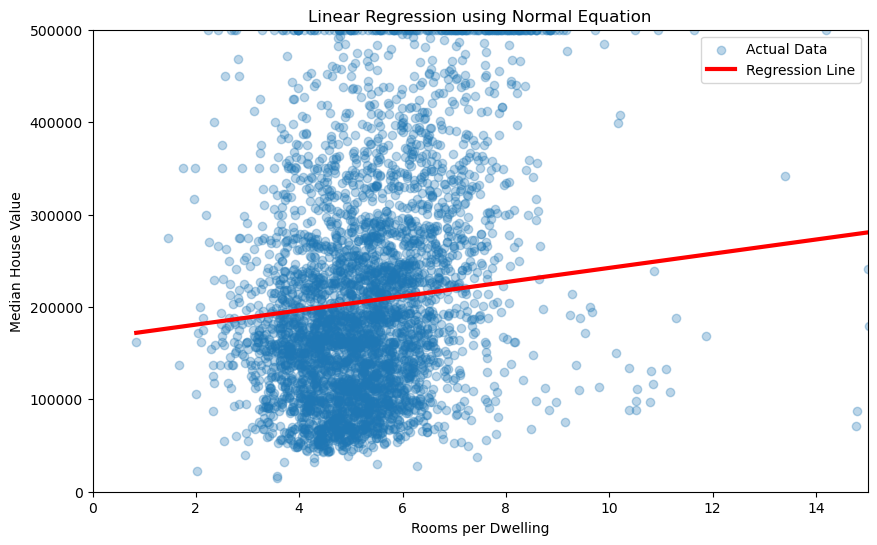

In [28]:
plt.figure(figsize=(10,6))
plt.scatter(
    x_test,                 
    y_test,                 
    alpha=0.3,              
    label='Actual Data'     
)
x_line = np.linspace(
    x_test.min(),
    x_test.max(),
    100
)
y_line = intercept + slope * x_line


plt.plot(
    x_line,
    y_line,
    color='red',            
    linewidth=3,           
    label='Regression Line' 
)
plt.xlim(0, 15)

plt.ylim(0, 500000)

plt.xlabel('Rooms per Dwelling')

plt.ylabel('Median House Value')

plt.title('Linear Regression using Normal Equation')

plt.legend()

plt.show()